In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
# The shortcut will now show up inside MyDrive just like a regular folder
os.listdir('/content/drive/MyDrive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


['Colab Notebooks', 'unaligned_39.pkl', 'Raw.zip']

In [ ]:
import os
import zipfile
from tqdm import tqdm

zip_path = '/content/drive/MyDrive/Raw.zip'
extract_path = '/content/dataset_raw'

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    members = zip_ref.infolist()
    total_bytes = sum(m.file_size for m in members)

    print(f"Total uncompressed size: {total_bytes / (1024**3):.2f} GB across {len(members)} items\n")

    # Progress bar tracking extracted bytes
    with tqdm(total=total_bytes, unit='B', unit_scale=True, unit_divisor=1024, desc="Extracting Raw.zip") as pbar:
        for member in members:
            zip_ref.extract(member, extract_path)
            pbar.update(member.file_size)

print(f"\n✅ Done! Files extracted to: {extract_path}")

Total uncompressed size: 11.09 GB across 6393 items



Extracting Raw.zip: 100%|██████████| 11.1G/11.1G [06:28<00:00, 30.7MB/s]


✅ Done! Files extracted to: /content/dataset_raw


In [ ]:
import os

# 1. Total files and directories breakdown
total_files = 0
total_size_bytes = 0

print("--- Directory Overview ---")
for root, dirs, files in os.walk(extract_path):
    level = root.replace(extract_path, '').count(os.sep)
    indent = ' ' * 4 * level
    print(f"{indent}📂 {os.path.basename(root)}/ ({len(files)} files)")

    total_files += len(files)
    for f in files:
        fp = os.path.join(root, f)
        if not os.path.islink(fp):
            total_size_bytes += os.path.getsize(fp)

print(f"\nTotal Files: {total_files}")
print(f"Total Extracted Size: {total_size_bytes / (1024**3):.2f} GB")

# 2. Preview top 5 sample files
print("\n--- Sample File Paths ---")
all_filepaths = []
for root, _, files in os.walk(extract_path):
    for f in files:
        all_filepaths.append(os.path.join(root, f))

for path in all_filepaths[:5]:
    print(path)

--- Directory Overview ---
📂 dataset_raw/ (0 files)
    📂 ch-simsv2s/ (1 files)
        📂 Raw/ (0 files)
            📂 video_0018/ (24 files)
            📂 video_0010/ (70 files)
            📂 video_0038/ (96 files)
            📂 video_0036/ (64 files)
            📂 aqgy5_0032/ (20 files)
            📂 aqgy5_0030/ (17 files)
            📂 video_0053/ (122 files)
            📂 video_xjzw/ (75 files)
            📂 video_0027/ (69 files)
            📂 aqgy4_0015/ (7 files)
            📂 aqgy4_0012/ (64 files)
            📂 aqgy4_0010/ (34 files)
            📂 video_0024/ (232 files)
            📂 aqgy4_0023/ (1 files)
            📂 test3/ (5 files)
            📂 aqgy3_0001/ (21 files)
            📂 video_0047/ (109 files)
            📂 aqgy4_0009/ (23 files)
            📂 video_0054/ (228 files)
            📂 video_0046/ (90 files)
            📂 aqgy5_0023/ (14 files)
            📂 test14/ (15 files)
            📂 test13/ (13 files)
            📂 aqgy3_0002/ (25 files)
            📂 aqgy5

In [ ]:
import pandas as pd

meta_path = '/content/dataset_raw/ch-simsv2s/meta.csv'
df = pd.read_csv(meta_path)

print("Dataset Shape:", df.shape)
print("\nColumns available:")
print(df.columns.tolist())

print("\n--- First 5 Rows ---")
display(df.head())

Dataset Shape: (4403, 9)

Columns available:
['video_id', 'clip_id', 'text', 'label', 'label_T', 'label_A', 'label_V', 'annotation', 'mode']

--- First 5 Rows ---


,video_id,clip_id,text,label,label_T,label_A,label_V,annotation,mode
0,video_0001,0001,我不想嫁给李茶,-1.0,-1.0,-1.0,-1.0,Negative,train
1,video_0001,0002,你这是嫁入豪门啊！,1.0,1.0,0.8,1.0,Positive,train
2,video_0001,0003,我不想嫁入什么豪门，我们不就是豪门吗？,-1.0,-0.8,-1.0,-1.0,Negative,test
3,video_0001,0004,有那么明显吗？,-1.0,-0.6,-1.0,-1.0,Negative,train
4,video_0001,0005,我在这消费这么多钱，我低血糖吃块糖还不行了,-1.0,-1.0,-1.0,-1.0,Negative,train


In [ ]:
df.describe()

,label,label_T,label_A,label_V
count,4403.000000,4403.000000,4403.000000,4403.000000
mean,-0.084147,-0.064342,-0.098501,-0.055349
std,0.666078,0.604575,0.598865,0.649615
min,-1.000000,-1.000000,-1.000000,-1.000000
25%,-0.800000,-0.600000,-0.600000,-0.600000
50%,0.000000,0.000000,0.000000,0.000000
75%,0.600000,0.400000,0.400000,0.600000
max,1.000000,1.000000,1.000000,1.000000


In [ ]:
import pandas as pd
import numpy as np

# Load metadata
meta_path = '/content/dataset_raw/ch-simsv2s/meta.csv'
df = pd.read_csv(meta_path)

print("="*50)
print(" 1. DATA SPLIT & LEAKAGE CHECK ")
print("="*50)
split_counts = df['mode'].value_counts()
print("Sample distribution across splits:")
for mode, count in split_counts.items():
    print(f"  - {mode}: {count} clips ({count/len(df)*100:.1f}%)")

# Check if parent videos leak across train/val/test splits
video_splits = df.groupby('video_id')['mode'].nunique()
leaked_videos = video_splits[video_splits > 1].count()
print(f"\nParent Videos spanning multiple splits: {leaked_videos}")
if leaked_videos == 0:
    print("✅ No data leakage! Clips from the same video are strictly kept inside a single split.")
else:
    print("⚠️ Warning: Data leakage detected! Same video appears in different splits.")



 1. DATA SPLIT & LEAKAGE CHECK 
Sample distribution across splits:
  - train: 2722 clips (61.8%)
  - test: 1034 clips (23.5%)
  - valid: 647 clips (14.7%)

Parent Videos spanning multiple splits: 129
⚠️ Warning: Data leakage detected! Same video appears in different splits.


In [ ]:
print("\n" + "="*50)
print(" 2. TARGET LABEL DISTRIBUTION & CORRELATION ")
print("="*50)
print("\nClass distribution ('annotation'):")
print(df['annotation'].value_counts(normalize=True).map(lambda x: f"{x*100:.2f}%"))

print("\nSummary Statistics of Continuous Labels:")
display(df[['label', 'label_T', 'label_A', 'label_V']].describe().T[['mean', 'std', 'min', '50%', 'max']])

# Correlation Matrix
corr = df[['label', 'label_T', 'label_A', 'label_V']].corr()
print("\nPearson Correlation Matrix with Fused Label:")
print(corr['label'].sort_values(ascending=False))




 2. TARGET LABEL DISTRIBUTION & CORRELATION 

Class distribution ('annotation'):
annotation
Negative    48.22%
Positive    39.68%
Neutral     12.11%
Name: proportion, dtype: object

Summary Statistics of Continuous Labels:


,mean,std,min,50%,max
label,-0.084147,0.666078,-1.0,0.0,1.0
label_T,-0.064342,0.604575,-1.0,0.0,1.0
label_A,-0.098501,0.598865,-1.0,0.0,1.0
label_V,-0.055349,0.649615,-1.0,0.0,1.0



Pearson Correlation Matrix with Fused Label:
label      1.000000
label_A    0.876462
label_V    0.841143
label_T    0.776240
Name: label, dtype: float64


In [ ]:
print("\n" + "="*50)
print(" 3. MODAL DISCREPANCY & CONFLICTS ")
print("="*50)
# Measure variance across modalities per clip
df['modal_std'] = df[['label_T', 'label_A', 'label_V']].std(axis=1)
high_conflict = df[df['modal_std'] > 0.8]
print(f"High-conflict clips (where T, A, and V disagree significantly): {len(high_conflict)} ({len(high_conflict)/len(df)*100:.1f}%)")

print("\nTop 3 High-Conflict Utterances:")
for idx, row in high_conflict[['text', 'label_T', 'label_A', 'label_V', 'annotation']].head(3).iterrows():
    print(f"  Text: '{row['text']}' | Annotation: {row['annotation']}")
    print(f"  -> T: {row['label_T']} | A: {row['label_A']} | V: {row['label_V']}\n")




 3. MODAL DISCREPANCY & CONFLICTS 
High-conflict clips (where T, A, and V disagree significantly): 131 (3.0%)

Top 3 High-Conflict Utterances:
  Text: '大渣集团的小职员？' | Annotation: Positive
  -> T: -0.4 | A: -0.6 | V: 1.0

  Text: '不是都快破产了吗' | Annotation: Positive
  -> T: -0.8 | A: -0.8 | V: 1.0

  Text: '你那点财务还需要助理' | Annotation: Positive
  -> T: -0.8 | A: -0.6 | V: 1.0



In [ ]:
print("="*50)
print(" 4. TEXT LENGTH ANALYSIS (For Tokenizer Max Length) ")
print("="*50)
df['text_len'] = df['text'].astype(str).str.len()
p50, p95, p99 = np.percentile(df['text_len'], [50, 95, 99])
print(f"Character length stats -> Median: {p50:.0f} | 95th Percentile: {p95:.0f} | 99th Percentile: {p99:.0f}")

 4. TEXT LENGTH ANALYSIS (For Tokenizer Max Length) 
Character length stats -> Median: 16 | 95th Percentile: 31 | 99th Percentile: 38


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupShuffleSplit

df = pd.read_csv('/content/dataset_raw/ch-simsv2s/meta.csv')

# GroupSplit at video_id level
gss_outer = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_val_idx, test_idx = next(gss_outer.split(df, groups=df['video_id']))

df_train_val = df.iloc[train_val_idx]
gss_inner = GroupShuffleSplit(n_splits=1, test_size=0.1875, random_state=42) # ~15% total val
train_sub_idx, val_sub_idx = next(gss_inner.split(df_train_val, groups=df_train_val['video_id']))

# Map back using original index mapping
val_idx = train_val_idx[val_sub_idx]
train_idx = train_val_idx[train_sub_idx]

df['clean_mode'] = 'train'
df.loc[val_idx, 'clean_mode'] = 'valid'
df.loc[test_idx, 'clean_mode'] = 'test'

# Verification check
leak_check = df.groupby('video_id')['clean_mode'].nunique()
print(f"Parent videos spanning multiple splits: {(leak_check > 1).sum()}")
assert (leak_check > 1).sum() == 0, "Leakage still present!"
print("✅ FIXED: 0 Parent Video Leakage across splits!\n")
print(df['clean_mode'].value_counts())

df.to_csv('/content/dataset_raw/ch-simsv2s/meta_clean.csv', index=False)

Parent videos spanning multiple splits: 0
✅ FIXED: 0 Parent Video Leakage across splits!

clean_mode
train    2799
test      900
valid     704
Name: count, dtype: int64


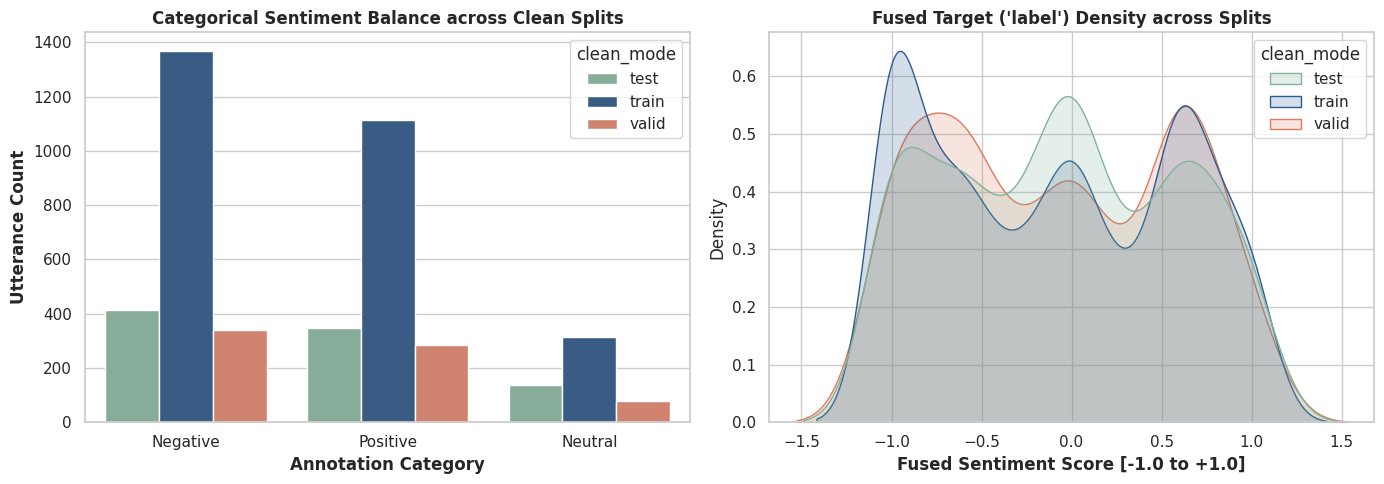

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font="sans-serif")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: Discrete Label Counts by Split
palette_splits = {"train": "#2b5c8f", "valid": "#e07a5f", "test": "#81b29a"}
sns.countplot(data=df, x='annotation', hue='clean_mode', palette=palette_splits, ax=axes[0])
axes[0].set_title("Categorical Sentiment Balance across Clean Splits", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Annotation Category", fontweight='bold')
axes[0].set_ylabel("Utterance Count", fontweight='bold')

# Plot B: Continuous Label Density Overlay
sns.kdeplot(data=df, x='label', hue='clean_mode', palette=palette_splits, common_norm=False, fill=True, alpha=0.2, ax=axes[1])
axes[1].set_title("Fused Target ('label') Density across Splits", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Fused Sentiment Score [-1.0 to +1.0]", fontweight='bold')

plt.tight_layout()
plt.show()

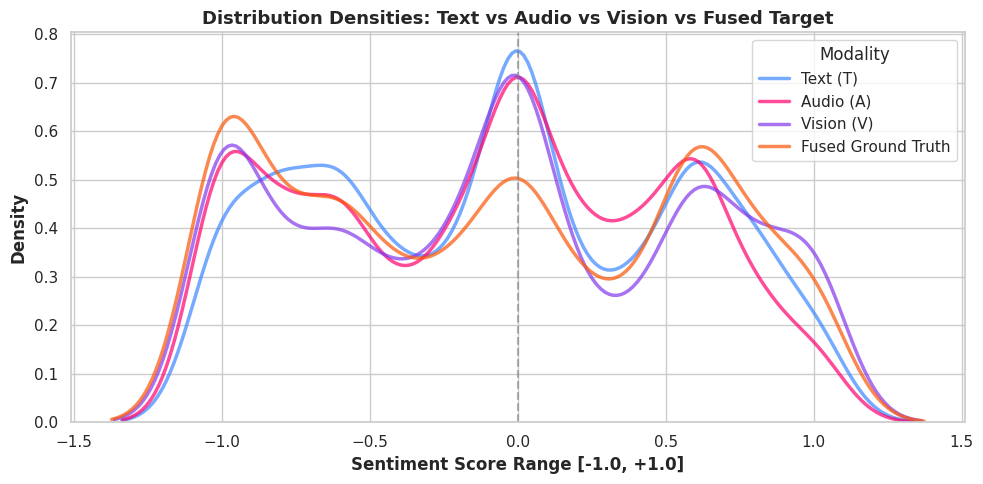

In [ ]:
plt.figure(figsize=(10, 5))

modal_cols = {'label_T': ('Text (T)', '#3A86FF'),
              'label_A': ('Audio (A)', '#FF006E'),
              'label_V': ('Vision (V)', '#8338EC'),
              'label': ('Fused Ground Truth', '#FB5607')}

for col, (label, color) in modal_cols.items():
    sns.kdeplot(df[col], label=label, color=color, linewidth=2.5, alpha=0.7)

plt.axvline(0, color='gray', linestyle='--', alpha=0.6)
plt.title("Distribution Densities: Text vs Audio vs Vision vs Fused Target", fontsize=13, fontweight='bold')
plt.xlabel("Sentiment Score Range [-1.0, +1.0]", fontweight='bold')
plt.ylabel("Density", fontweight='bold')
plt.legend(title="Modality", frameon=True)
plt.tight_layout()
plt.show()

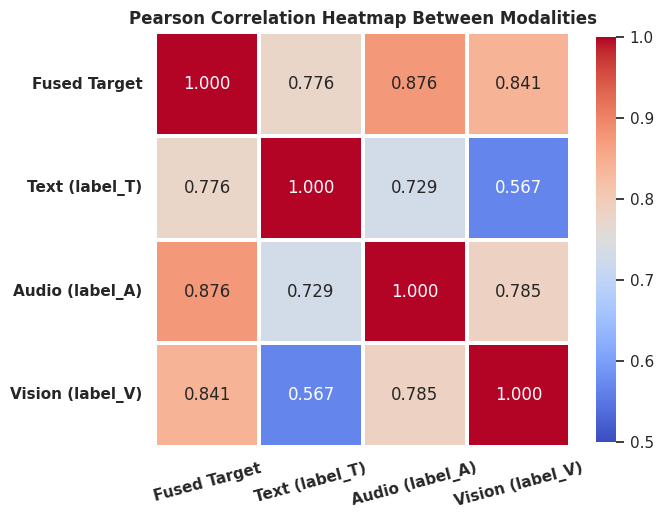

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))

corr_matrix = df[['label', 'label_T', 'label_A', 'label_V']].corr()

sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap="coolwarm", vmin=0.5, vmax=1.0,
            square=True, cbar_kws={"shrink": 0.8}, linewidths=1.5, ax=ax)

ax.set_xticklabels(['Fused Target', 'Text (label_T)', 'Audio (label_A)', 'Vision (label_V)'], rotation=15, fontweight='bold')
ax.set_yticklabels(['Fused Target', 'Text (label_T)', 'Audio (label_A)', 'Vision (label_V)'], rotation=0, fontweight='bold')
plt.title("Pearson Correlation Heatmap Between Modalities", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

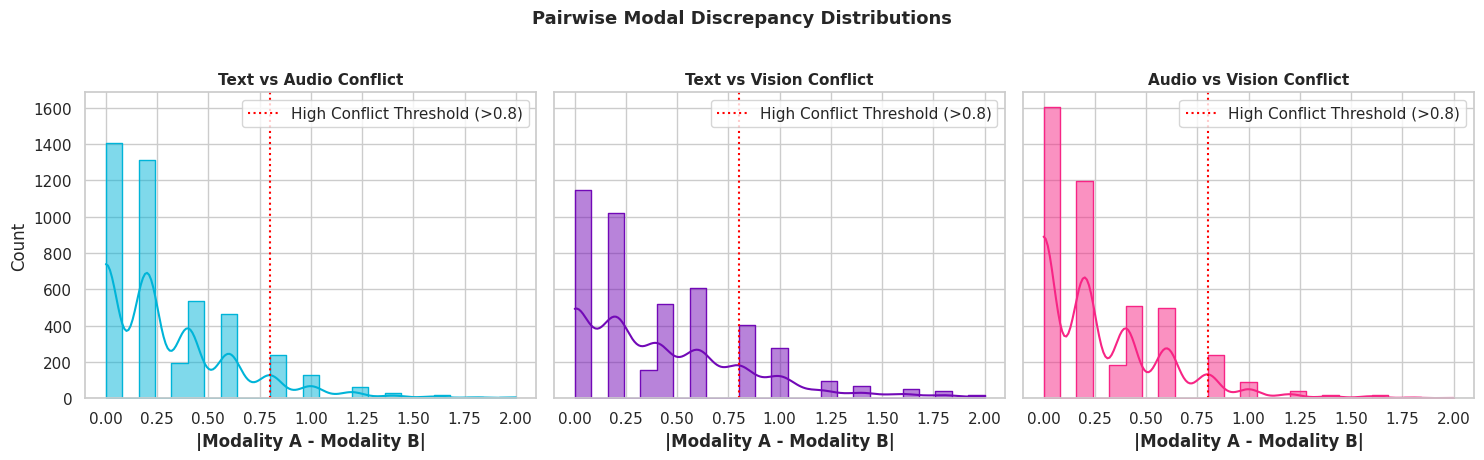

In [ ]:
# Compute pairwise differences
df['diff_TA'] = np.abs(df['label_T'] - df['label_A'])
df['diff_TV'] = np.abs(df['label_T'] - df['label_V'])
df['diff_AV'] = np.abs(df['label_A'] - df['label_V'])

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)

conflict_pairs = [
    ('diff_TA', 'Text vs Audio Conflict', '#00B4D8'),
    ('diff_TV', 'Text vs Vision Conflict', '#7209B7'),
    ('diff_AV', 'Audio vs Vision Conflict', '#F72585')
]

for i, (col, title, color) in enumerate(conflict_pairs):
    sns.histplot(df[col], bins=25, kde=True, color=color, ax=axes[i], element='step')
    axes[i].set_title(title, fontsize=11, fontweight='bold')
    axes[i].set_xlabel("|Modality A - Modality B|", fontweight='bold')
    axes[i].axvline(0.8, color='red', linestyle=':', label='High Conflict Threshold (>0.8)')
    axes[i].legend(loc='upper right')

plt.suptitle("Pairwise Modal Discrepancy Distributions", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

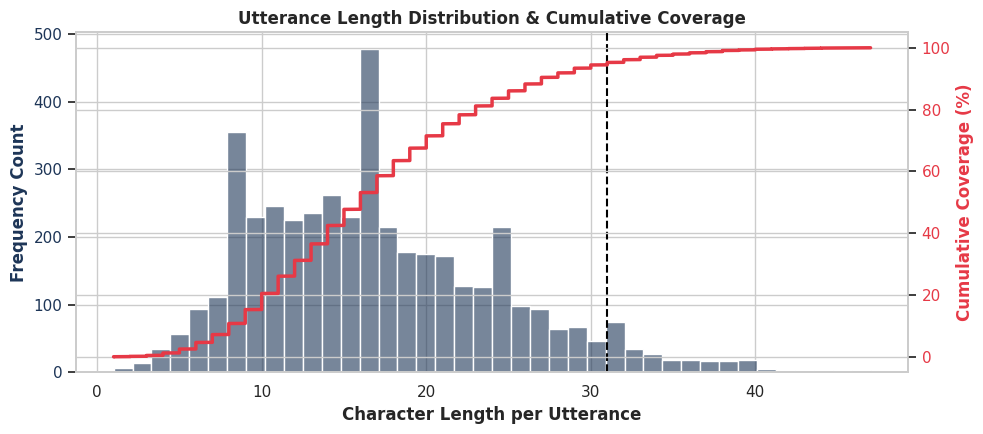

In [ ]:
df['char_len'] = df['text'].astype(str).str.len()

fig, ax1 = plt.subplots(figsize=(10, 4.5))

color = '#1D3557'
sns.histplot(df['char_len'], bins=40, color=color, kde=False, ax=ax1, alpha=0.6)
ax1.set_xlabel('Character Length per Utterance', fontweight='bold')
ax1.set_ylabel('Frequency Count', color=color, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=color)

# Cumulative percentage curve on twin axis
ax2 = ax1.twinx()
sorted_lens = np.sort(df['char_len'])
cumulative = np.arange(1, len(sorted_lens) + 1) / len(sorted_lens) * 100
ax2.plot(sorted_lens, cumulative, color='#E63946', linewidth=2.5, label='Cumulative %')
ax2.set_ylabel('Cumulative Coverage (%)', color='#E63946', fontweight='bold')
ax2.tick_params(axis='y', labelcolor='#E63946')

p95 = np.percentile(df['char_len'], 95)
ax1.axvline(p95, color='black', linestyle='--', label=f'95th Percentile ({int(p95)} chars)')

plt.title("Utterance Length Distribution & Cumulative Coverage", fontsize=12, fontweight='bold')
fig.tight_layout()
plt.show()

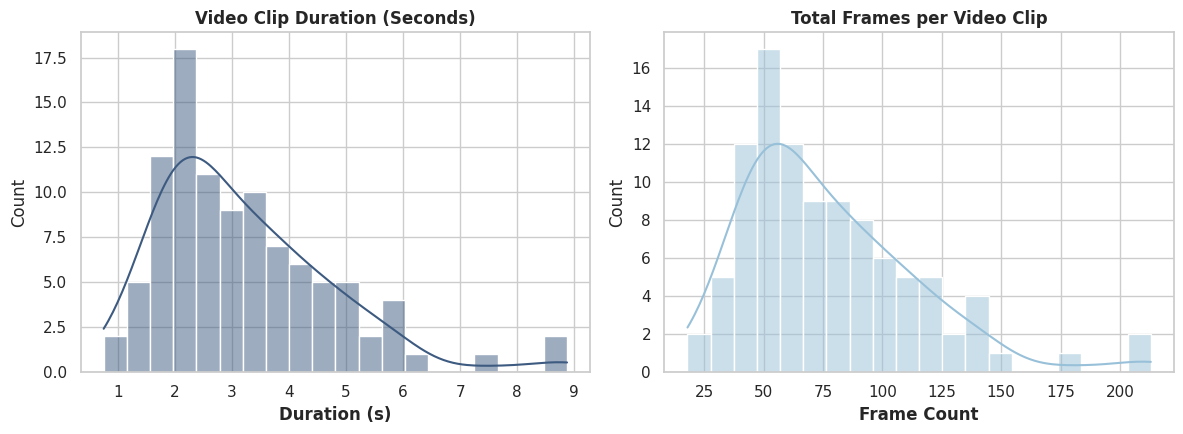

Average Duration: 3.22s | Median FPS: 24.0
Suggested Video Uniform Frame Sampling rate: 16 or 32 frames per clip


In [ ]:
import glob
import cv2

# Sample 100 video files across directory to profile frame specs
sample_video_paths = glob.glob('/content/dataset_raw/ch-simsv2s/Raw/*/*.mp4')[:100]

durations, frame_counts, fps_list = [], [], []

for vp in sample_video_paths:
    cap = cv2.VideoCapture(vp)
    if not cap.isOpened():
        continue
    fps = cap.get(cv2.CAP_PROP_FPS)
    frames = cap.get(cv2.CAP_PROP_FRAME_COUNT)
    if fps > 0:
        durations.append(frames / fps)
        frame_counts.append(frames)
        fps_list.append(fps)
    cap.release()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.histplot(durations, bins=20, color='#3D5A80', kde=True, ax=axes[0])
axes[0].set_title("Video Clip Duration (Seconds)", fontweight='bold')
axes[0].set_xlabel("Duration (s)", fontweight='bold')

sns.histplot(frame_counts, bins=20, color='#98C1D9', kde=True, ax=axes[1])
axes[1].set_title("Total Frames per Video Clip", fontweight='bold')
axes[1].set_xlabel("Frame Count", fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Average Duration: {np.mean(durations):.2f}s | Median FPS: {np.median(fps_list):.1f}")
print(f"Suggested Video Uniform Frame Sampling rate: 16 or 32 frames per clip")

Total video files found: 4479
 1. VIDEO SPATIAL METRICS SUMMARY 
Total Videos Analyzed: 4479

Resolution Breakdown:
resolution
1920x1080    2236
1280x720      725
1920x800      193
576x432       170
1280x544      147
1920x806       95
864x486        86
768x576        83
1280x540       78
1920x1078      64
1920x816       61
1920x808       59
1920x1040      48
1280x580       47
2824x2160      42
1280x480       40
1416x1080      38
1920x760       38
848x352        35
1024x576       35
1920x804       35
960x540        35
1920x720       34
1920x1072      17
1920x864       12
1280x536       11
1080x422        8
1580x888        7
Name: count, dtype: int64

Aspect Ratio Breakdown:
aspect_ratio
1.78    3188
1.33     253
2.35     208
2.40     193
2.38     154
1.31      80
2.37      78
2.67      74
1.85      48
2.21      47
2.39      46
2.53      38
2.41      35
1.79      17
2.22      12
2.56       8
Name: count, dtype: int64


/tmp/ipykernel_5050/1135329162.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_5050/1135329162.py:53: UserWarning: 
The palette list has fewer values (5) than needed (16) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(


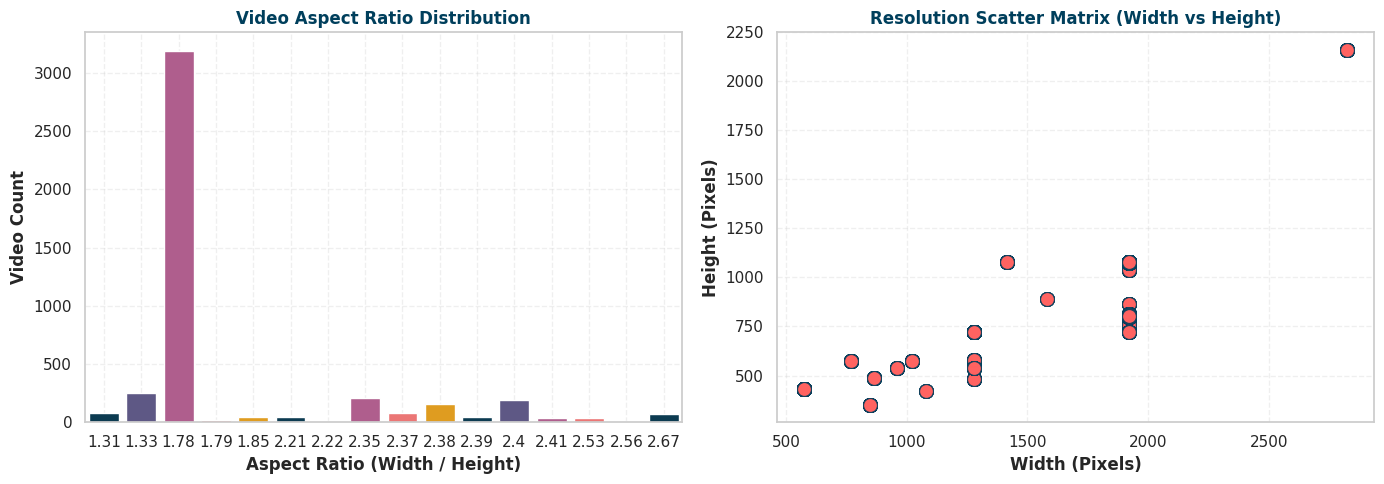

In [ ]:
import glob
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sample video files across directories
video_files = glob.glob('/content/dataset_raw/ch-simsv2s/Raw/*/*.mp4')
print(f"Total video files found: {len(video_files)}")

resolution_data = []

for vp in video_files:
    cap = cv2.VideoCapture(vp)
    if not cap.isOpened():
        continue

    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if width > 0 and height > 0:
        aspect_ratio = round(width / height, 2)
        resolution_data.append({
            'path': vp,
            'width': width,
            'height': height,
            'resolution': f"{width}x{height}",
            'aspect_ratio': aspect_ratio,
            'fps': round(fps, 2),
            'total_frames': frames,
            'duration_sec': round(frames / fps, 2) if fps > 0 else 0
        })
    cap.release()

df_video = pd.DataFrame(resolution_data)

# Print Summary Statistics
print("="*60)
print(" 1. VIDEO SPATIAL METRICS SUMMARY ")
print("="*60)
print(f"Total Videos Analyzed: {len(df_video)}")
print("\nResolution Breakdown:")
print(df_video['resolution'].value_counts())
print("\nAspect Ratio Breakdown:")
print(df_video['aspect_ratio'].value_counts())

# Plotting: High Contrast Palette (#003f5c, #ff6361, #ffa600)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: Aspect Ratio Distribution
sns.countplot(
    data=df_video, x='aspect_ratio',
    palette=['#003f5c', '#58508d', '#bc5090', '#ff6361', '#ffa600'],
    ax=axes[0]
)
axes[0].set_title("Video Aspect Ratio Distribution", fontsize=12, fontweight='bold', color='#003f5c')
axes[0].set_xlabel("Aspect Ratio (Width / Height)", fontweight='bold')
axes[0].set_ylabel("Video Count", fontweight='bold')
axes[0].grid(True, linestyle='--', alpha=0.3)

# Plot B: Joint Resolution Scatter
sns.scatterplot(
    data=df_video, x='width', y='height',
    s=100, color='#ff6361', edgecolor='#003f5c', alpha=0.8, ax=axes[1]
)
axes[1].set_title("Resolution Scatter Matrix (Width vs Height)", fontsize=12, fontweight='bold', color='#003f5c')
axes[1].set_xlabel("Width (Pixels)", fontweight='bold')
axes[1].set_ylabel("Height (Pixels)", fontweight='bold')
axes[1].grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Cell 1: Environment Setup & Library Imports
!pip install -q transformers torchaudio pandas numpy tqdm torch

import os
import glob
import pickle
import numpy as np
import pandas as pd
import torch
import torchaudio
from tqdm import tqdm
from transformers import BertTokenizer, BertModel, Wav2Vec2Model, Wav2Vec2Processor

# Hardware check
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Active compute device: {device}")

# Path Configs (Adjust paths to match your folder structure)
META_CSV_PATH = '/content/dataset_raw/ch-simsv2s/meta_clean.csv'
RAW_VIDEO_DIR = '/content/dataset_raw/ch-simsv2s/Raw'
OPENFACE_CSV_DIR = '/content/openface_csvs'
OUTPUT_PKL_PATH = '/content/dataset_raw/ch-simsv2s/simsv2_features.pkl'

df_meta = pd.read_csv(META_CSV_PATH)
print(f"✅ Metadata loaded. Total clips: {len(df_meta)}")

✅ Active compute device: cuda
✅ Metadata loaded. Total clips: 4403


In [ ]:
# Cell 2: Initialize Deep Learning Models for Text and Audio (FIXED)
from transformers import BertTokenizer, BertModel, Wav2Vec2Model, Wav2Vec2FeatureExtractor

print("⏳ Loading BERT and Wav2Vec2 models into memory...")

# 1. Text Extractor (bert-base-chinese)
text_tokenizer = BertTokenizer.from_pretrained('bert-base-chinese')
text_model = BertModel.from_pretrained('bert-base-chinese').to(device).eval()

# 2. Audio Extractor (chinese-wav2vec2-base)
# Fixed: Using FeatureExtractor instead of Processor (does not require vocab.json)
audio_processor = Wav2Vec2FeatureExtractor.from_pretrained('TencentGameMate/chinese-wav2vec2-base')
audio_model = Wav2Vec2Model.from_pretrained('TencentGameMate/chinese-wav2vec2-base').to(device).eval()

print("✅ Text and Audio neural encoders ready.")

# Helper Extraction Functions
def extract_text_feature(text, max_len=48):
    """Tokenizes text and returns hidden state representation (T_t x 768)"""
    inputs = text_tokenizer(
        text,
        return_tensors='pt',
        max_length=max_len,
        padding='max_length',
        truncation=True
    ).to(device)

    with torch.no_grad():
        outputs = text_model(**inputs)
        feature = outputs.last_hidden_state.squeeze(0).cpu().numpy()
    return feature

def extract_audio_feature(video_path, target_frames=50):
    """Extracts raw waveform, passes through wav2vec2, and pools to fixed frames (T_a x 768)"""
    try:
        waveform, sample_rate = torchaudio.load(video_path)
        # Convert stereo to mono if needed
        if waveform.shape[0] > 1:
            waveform = torch.mean(waveform, dim=0, keepdim=True)

        if sample_rate != 16000:
            resampler = torchaudio.transforms.Resample(sample_rate, 16000)
            waveform = resampler(waveform)

        # FeatureExtractor takes raw audio numpy array or tensor directly
        inputs = audio_processor(
            waveform.squeeze(0).numpy(),
            sampling_rate=16000,
            return_tensors="pt"
        ).input_values.to(device)

        with torch.no_grad():
            outputs = audio_model(inputs)
            feature = outputs.last_hidden_state.squeeze(0).cpu().numpy() # Shape: (Seq_len, 768)

        # Uniform temporal sampling / pooling to fix target frame count
        if feature.shape[0] >= target_frames:
            indices = np.linspace(0, feature.shape[0] - 1, target_frames, dtype=int)
            feature = feature[indices]
        else:
            # Zero padding if audio sequence is shorter than target frames
            pad_len = target_frames - feature.shape[0]
            feature = np.pad(feature, ((0, pad_len), (0, 0)), mode='constant')

        return feature.astype(np.float32)

    except Exception as e:
        # Fallback for missing/corrupted audio tracks
        return np.zeros((target_frames, 768), dtype=np.float32)

def extract_vision_feature(clip_id, target_frames=30):
    """Reads OpenFace CSV, extracts AUs and Head Pose features (T_v x 35)"""
    csv_path = os.path.join(OPENFACE_CSV_DIR, f"{clip_id}.csv")

    if os.path.exists(csv_path):
        of_df = pd.read_csv(csv_path)
        of_df.columns = of_df.columns.str.strip()

        feature_cols = [c for c in of_df.columns if c.startswith('AU') or c.startswith('pose')]

        if len(feature_cols) > 0:
            features = of_df[feature_cols].fillna(0).values

            if features.shape[0] >= target_frames:
                indices = np.linspace(0, features.shape[0] - 1, target_frames, dtype=int)
                features = features[indices]
            else:
                pad_len = target_frames - features.shape[0]
                features = np.pad(features, ((0, pad_len), (0, 0)), mode='constant')

            return features.astype(np.float32)

    return np.zeros((target_frames, 35), dtype=np.float32)

⏳ Loading BERT and Wav2Vec2 models into memory...


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/110k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/269k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/624 [00:00<?, ?B/s]

...

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  380MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

[transformers] Wav2Vec2Model LOAD REPORT from: TencentGameMate/chinese-wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_hid.bias             | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Text and Audio neural encoders ready.


In [ ]:
# Cell 3: Process All Splits (Train, Valid, Test) - FIXED
def process_split(split_df, split_name):
    split_data = {
        'text': [],
        'audio': [],
        'vision': [],
        'labels': [],
        'labels_T': [],
        'labels_A': [],
        'labels_V': [],
        'id': []
    }

    # Progress bar using passed split_name instead of unbound row variable
    for idx, row in tqdm(split_df.iterrows(), total=len(split_df), desc=f"Processing {split_name.upper()}"):
        video_clip_id = f"{row['video_id']}/{row['clip_id']}"
        video_path = os.path.join(RAW_VIDEO_DIR, f"{row['video_id']}", f"{row['clip_id']}.mp4")

        # 1. Extract Text Features
        text_feat = extract_text_feature(row['text'])

        # 2. Extract Audio Features
        audio_feat = extract_audio_feature(video_path)

        # 3. Extract Visual Features (OpenFace AUs + Pose)
        vision_feat = extract_vision_feature(row['clip_id'])

        # Append samples
        split_data['text'].append(text_feat)
        split_data['audio'].append(audio_feat)
        split_data['vision'].append(vision_feat)
        split_data['labels'].append(row['label'])
        split_data['labels_T'].append(row['label_T'])
        split_data['labels_A'].append(row['label_A'])
        split_data['labels_V'].append(row['label_V'])
        split_data['id'].append(video_clip_id)

    # Convert lists to NumPy matrices
    for key in ['text', 'audio', 'vision', 'labels', 'labels_T', 'labels_A', 'labels_V']:
        split_data[key] = np.array(split_data[key], dtype=np.float32)

    return split_data

print("🚀 Starting Multimodal Feature Extraction Pipeline...")

# Build nested dictionary split by clean_mode ('train', 'valid', 'test')
dataset_pkl = {
    'train': process_split(df_meta[df_meta['clean_mode'] == 'train'], 'train'),
    'valid': process_split(df_meta[df_meta['clean_mode'] == 'valid'], 'valid'),
    'test': process_split(df_meta[df_meta['clean_mode'] == 'test'], 'test')
}

print("✅ Feature extraction finished successfully.")

🚀 Starting Multimodal Feature Extraction Pipeline...


model.safetensors: reconstructing file:   0%|          |  0.00B /  380MB            



Processing TRAIN:   0%|          | 0/2799 [00:00<?, ?it/s]

model.safetensors: downloading bytes:           |  0.00B            



Processing TRAIN:   0%|          | 1/2799 [00:07<5:32:13,  7.12s/it]

Processing TRAIN:   0%|          | 2/2799 [00:07<2:25:30,  3.12s/it]

Processing TRAIN:   0%|          | 3/2799 [00:07<1:26:21,  1.85s/it]

Processing TRAIN:   0%|          | 4/2799 [00:08<1:00:27,  1.30s/it]

Processing TRAIN:   0%|          | 5/2799 [00:08<42:25,  1.10it/s]  

Processing TRAIN:   0%|          | 6/2799 [00:08<32:45,  1.42it/s]

Processing TRAIN:   0%|          | 7/2799 [00:08<25:35,  1.82it/s]

Processing TRAIN:   0%|          | 8/2799 [00:09<20:43,  2.25it/s]

Processing TRAIN:   0%|          | 9/2799 [00:09<16:54,  2.75it/s]

Processing TRAIN:   0%|          | 10/2799 [00:09<14:06,  3.30it/s]

Processing TRAIN:   0%|          | 11/2799 [00:09<13:03,  3.56it/s]

Processing TRAIN:   0%|          | 12/2799 [00:10<12:31,  3.71it/s]

Processing TRAIN:   0%|          | 13/2799 [00:10<12:00,  3.86it/s]

Processing TRAIN:   1%|          | 14/2799 [00:10<11:02,  4.20it/s]

Processing TRAIN:   1%|        

✅ Feature extraction finished successfully.


In [ ]:
# Cell 4: Serialize Dataset to Pickle and Verify Tensor Dimensions
import os
import pickle

# 1. Ensure target directory exists
os.makedirs(os.path.dirname(OUTPUT_PKL_PATH), exist_ok=True)

# 2. Serialize dataset dictionary
print(f"⏳ Saving pickle file to {OUTPUT_PKL_PATH}...")
with open(OUTPUT_PKL_PATH, 'wb') as f:
    pickle.dump(dataset_pkl, f, protocol=4)

print(f"🎉 Pickle file successfully saved!\n")

# 3. Verify tensor shapes for each split
for split in ['train', 'valid', 'test']:
    print(f"--- Split: {split.upper()} ---")
    print(f"  Text Tensor Shape   : {dataset_pkl[split]['text'].shape}")    # Expected: (N, 48, 768)
    print(f"  Audio Tensor Shape  : {dataset_pkl[split]['audio'].shape}")   # Expected: (N, 50, 768)
    print(f"  Vision Tensor Shape : {dataset_pkl[split]['vision'].shape}")  # Expected: (N, 30, 35)
    print(f"  Labels Shape        : {dataset_pkl[split]['labels'].shape}")  # Expected: (N,)
    print(f"  Total Samples       : {len(dataset_pkl[split]['id'])}\n")

⏳ Saving pickle file to /content/dataset_raw/ch-simsv2s/simsv2_features.pkl...
🎉 Pickle file successfully saved!

--- Split: TRAIN ---
  Text Tensor Shape   : (2799, 48, 768)
  Audio Tensor Shape  : (2799, 50, 768)
  Vision Tensor Shape : (2799, 30, 35)
  Labels Shape        : (2799,)
  Total Samples       : 2799

--- Split: VALID ---
  Text Tensor Shape   : (704, 48, 768)
  Audio Tensor Shape  : (704, 50, 768)
  Vision Tensor Shape : (704, 30, 35)
  Labels Shape        : (704,)
  Total Samples       : 704

--- Split: TEST ---
  Text Tensor Shape   : (900, 48, 768)
  Audio Tensor Shape  : (900, 50, 768)
  Vision Tensor Shape : (900, 30, 35)
  Labels Shape        : (900,)
  Total Samples       : 900



In [ ]:
# Cell: Copy local dataset file directly to Google Drive
import os
import shutil

# 2. Define source and destination paths
source_path = '/content/dataset_raw/ch-simsv2s/simsv2_features.pkl'
dest_dir = '/content/drive/MyDrive/MMSA_Datasets'  # Folder in your Drive
dest_path = os.path.join(dest_dir, 'simsv2_features.pkl')

# 3. Create destination directory if it doesn't exist
os.makedirs(dest_dir, exist_ok=True)

# 4. Check if file exists and transfer
if os.path.exists(source_path):
    print(f"📦 Copying file from {source_path} to Google Drive...")
    shutil.copy(source_path, dest_path)
    print(f"✅ Successfully copied to Google Drive!")
    print(f"📍 Drive Path: MyDrive/MMSA_Datasets/simsv2_features.pkl")
else:
    print(f"❌ Source file not found at: {source_path}")

📦 Copying file from /content/dataset_raw/ch-simsv2s/simsv2_features.pkl to Google Drive...
✅ Successfully copied to Google Drive!
📍 Drive Path: MyDrive/MMSA_Datasets/simsv2_features.pkl


In [ ]:
#Now we will analyze official pkl files

In [ ]:
# Cell 1: Mount Google Drive and Load Pickle
import os
import pickle

# 2. File Path
ZIP_PATH = '/content/drive/MyDrive/unaligned_39.pkl'

if not os.path.exists(ZIP_PATH):
    raise FileNotFoundError(f"❌ File not found at {ZIP_PATH}. Please verify the file name and path in Drive.")

print(f"⏳ Loading feature pickle from: {ZIP_PATH}...")

# 3. Load Pickle File
with open(ZIP_PATH, 'rb') as f:
    dataset = pickle.load(f)

print("✅ Pickle file loaded successfully!")
print(f"🔑 Available splits/keys in pickle: {list(dataset.keys())}")

⏳ Loading feature pickle from: /content/drive/MyDrive/unaligned_39.pkl...
✅ Pickle file loaded successfully!
🔑 Available splits/keys in pickle: ['train', 'valid', 'test']


In [ ]:
# Cell 1: Structural Inspection (DataFrames, Shapes, Data Types, Summary)
import pandas as pd
import numpy as np

# Helper function to extract info safely regardless of dictionary key naming
def get_modality_keys(split_dict):
    t_k = next((k for k in ['text', 'feature_T', 'text_mmsa'] if k in split_dict), None)
    a_k = next((k for k in ['audio', 'feature_A', 'audio_mmsa'] if k in split_dict), None)
    v_k = next((k for k in ['vision', 'feature_V', 'vision_mmsa'] if k in split_dict), None)
    l_k = next((k for k in ['labels', 'label', 'regression_labels'] if k in split_dict), None)
    id_k = next((k for k in ['id', 'raw_text', 'ids'] if k in split_dict), None)
    return t_k, a_k, v_k, l_k, id_k

# 1. Inspect Shapes and Data Types across splits
inspect_rows = []
for split in ['train', 'valid', 'test']:
    if split in dataset:
        t_k, a_k, v_k, l_k, _ = get_modality_keys(dataset[split])

        row = {
            'Split': split.upper(),
            'Sample Count': len(dataset[split][l_k]),
            'Text Key/Shape': f"{t_k}: {dataset[split][t_k].shape}",
            'Audio Key/Shape': f"{a_k}: {dataset[split][a_k].shape}",
            'Vision Key/Shape': f"{v_k}: {dataset[split][v_k].shape}",
            'Label Dtype': dataset[split][l_k].dtype,
            'Feature Dtype': dataset[split][t_k].dtype
        }
        inspect_rows.append(row)

df_structure = pd.DataFrame(inspect_rows)
print("📋 --- DATASET STRUCTURE & TENSOR SHAPES ---")
display(df_structure)

# 2. Convert Train Split Labels into DataFrame for .describe()
t_k, a_k, v_k, l_k, id_k = get_modality_keys(dataset['train'])
df_train_labels = pd.DataFrame({
    'regression_label': np.array(dataset['train'][l_k]).squeeze()
})

print("\n📊 --- TRAIN LABEL DESCRIPTIVE STATISTICS (.describe()) ---")
display(df_train_labels.describe().T)

📋 --- DATASET STRUCTURE & TENSOR SHAPES ---


,Split,Sample Count,Text Key/Shape,Audio Key/Shape,Vision Key/Shape,Label Dtype,Feature Dtype
0,TRAIN,1368,"text: (1368, 39, 768)","audio: (1368, 400, 33)","vision: (1368, 55, 709)",float64,float32
1,VALID,456,"text: (456, 39, 768)","audio: (456, 400, 33)","vision: (456, 55, 709)",float64,float32
2,TEST,457,"text: (457, 39, 768)","audio: (457, 400, 33)","vision: (457, 55, 709)",float64,float32



📊 --- TRAIN LABEL DESCRIPTIVE STATISTICS (.describe()) ---


,count,mean,std,min,25%,50%,75%,max
regression_label,1368.0,-0.192836,0.691155,-1.0,-1.0,-0.2,0.2,1.0


In [ ]:
# Cell 1: Construct Tabular DataFrames from MMSA Pickle Keys
import pandas as pd
import numpy as np

dfs = {}

for split in ['train', 'valid', 'test']:
    if split not in dataset:
        continue

    split_data = dataset[split]

    # Extract keys dynamically
    t_k = next((k for k in ['text', 'feature_T', 'text_mmsa'] if k in split_data), None)
    a_k = next((k for k in ['audio', 'feature_A', 'audio_mmsa'] if k in split_data), None)
    v_k = next((k for k in ['vision', 'feature_V', 'vision_mmsa'] if k in split_data), None)
    l_k = next((k for k in ['labels', 'label', 'regression_labels'] if k in split_data), None)
    id_k = next((k for k in ['id', 'raw_text', 'ids'] if k in split_data), None)

    # 1. Targets and IDs
    labels = np.array(split_data[l_k]).squeeze()
    sample_ids = split_data[id_k] if id_k else [f"{split}_{i}" for i in range(len(labels))]

    # 2. Extract modality sequence lengths and vector feature norms
    t_feats = split_data[t_k]
    a_feats = split_data[a_k]
    v_feats = split_data[v_k]

    df_split = pd.DataFrame({
        'sample_id': sample_ids,
        'split': split,
        'label': labels,
        # Sequence Lengths per modality
        'seq_len_text': [t_feats[i].shape[0] for i in range(len(labels))],
        'seq_len_audio': [a_feats[i].shape[0] for i in range(len(labels))],
        'seq_len_vision': [v_feats[i].shape[0] for i in range(len(labels))],
        # Mean Feature Energy / Norms per modality
        'text_feat_norm': [np.linalg.norm(t_feats[i]) for i in range(len(labels))],
        'audio_feat_norm': [np.linalg.norm(a_feats[i]) for i in range(len(labels))],
        'vision_feat_norm': [np.linalg.norm(v_feats[i]) for i in range(len(labels))],
    })

    dfs[split] = df_split

# Combine into master DataFrame
df_all = pd.concat(dfs.values(), ignore_index=True)

print("✅ Master DataFrame (df_all) created successfully!")
print(f"Shape: {df_all.shape} | Columns: {list(df_all.columns)}")
display(df_all.head())

✅ Master DataFrame (df_all) created successfully!
Shape: (2281, 9) | Columns: ['sample_id', 'split', 'label', 'seq_len_text', 'seq_len_audio', 'seq_len_vision', 'text_feat_norm', 'audio_feat_norm', 'vision_feat_norm']


,sample_id,split,label,seq_len_text,seq_len_audio,seq_len_vision,text_feat_norm,audio_feat_norm,vision_feat_norm
0,video_0018$_$0004,train,-1.0,39,400,55,128.965805,1758.059264,8.688335e+03
1,video_0029$_$0010,train,-1.0,39,400,55,134.309601,3964.668579,2.446944e+08
2,video_0038$_$0040,train,0.6,39,400,55,126.868629,2708.988649,7.654570e+03
3,video_0032$_$0006,train,-0.2,39,400,55,132.569778,5768.577458,1.330954e+04
4,video_0025$_$0006,train,-1.0,39,400,55,126.715919,2107.908877,6.276658e+03


In [ ]:
import numpy as np
import copy

# Create a copy of the dataset dictionary to hold cleaned and normalized features
dataset_clean = copy.deepcopy(dataset)

# Helper to locate modality keys dynamically
def get_keys(split_dict):
    t_k = next((k for k in ['text', 'feature_T', 'text_mmsa'] if k in split_dict), None)
    a_k = next((k for k in ['audio', 'feature_A', 'audio_mmsa'] if k in split_dict), None)
    v_k = next((k for k in ['vision', 'feature_V', 'vision_mmsa'] if k in split_dict), None)
    l_k = next((k for k in ['labels', 'label', 'regression_labels'] if k in split_dict), None)
    id_k = next((k for k in ['id', 'raw_text', 'ids'] if k in split_dict), None)
    return t_k, a_k, v_k, l_k, id_k

train_t_k, train_a_k, train_v_k, train_l_k, train_id_k = get_keys(dataset['train'])

# ==============================================================================
# STEP 1: DETECT & REMOVE OUTLIERS IN TRAIN SET VIA IQR (Visual Norms)
# ==============================================================================
train_v_feats = dataset['train'][train_v_k] # Shape: (1368, 55, d_v)
v_norms = np.array([np.linalg.norm(sample) for sample in train_v_feats])

# Compute IQR
Q1 = np.percentile(v_norms, 25)
Q3 = np.percentile(v_norms, 75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

# Boolean mask for non-outliers
inlier_mask = (v_norms >= lower_bound) & (v_norms <= upper_bound)
num_outliers = np.sum(~inlier_mask)

print("🔍 --- STEP 1: TRAIN SET IQR OUTLIER DETECTION ---")
print(f"Q1 (25th percentile) : {Q1:.2f}")
print(f"Q3 (75th percentile) : {Q3:.2f}")
print(f"IQR                  : {IQR:.2f}")
print(f"Upper Bound          : {upper_bound:.2f}")
print(f"Outliers Identified  : {num_outliers} / {len(v_norms)} ({num_outliers / len(v_norms) * 100:.2f}%)")

🔍 --- STEP 1: TRAIN SET IQR OUTLIER DETECTION ---
Q1 (25th percentile) : 9783.20
Q3 (75th percentile) : 14564.92
IQR                  : 4781.72
Upper Bound          : 21737.49
Outliers Identified  : 125 / 1368 (9.14%)


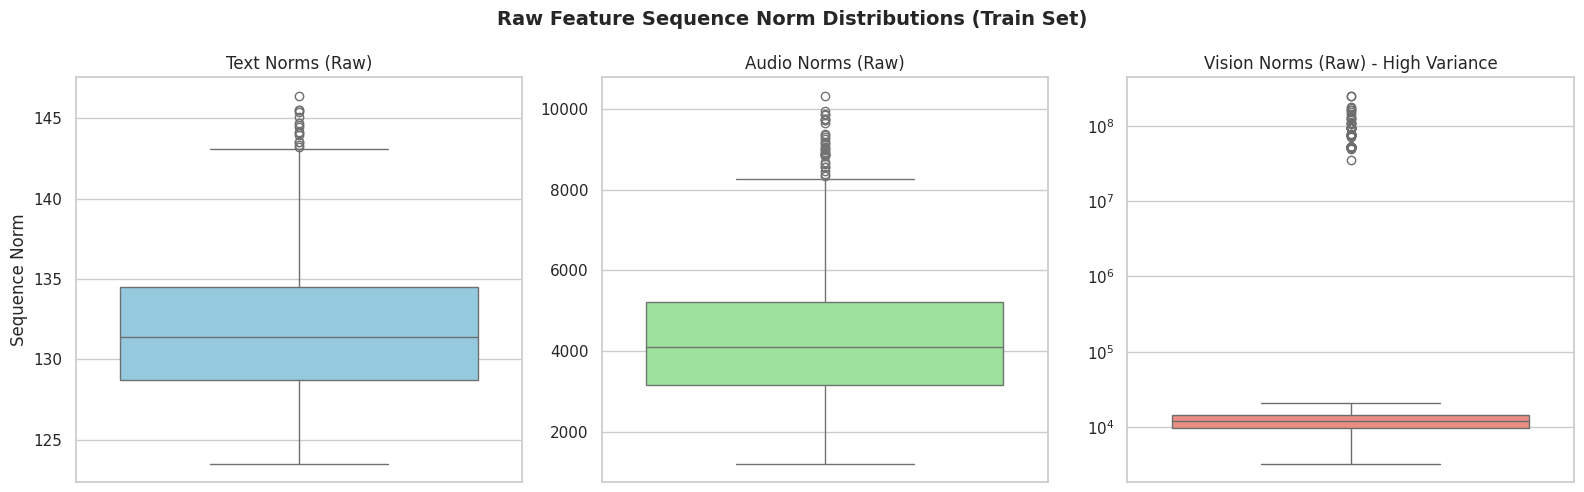

In [ ]:
# Cell: Box & Whisker Visualizations for Outlier Diagnostics
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Compute sequence-level Frobenius norms for each sample in Train
train_v_raw = dataset['train'][train_v_k]
train_a_raw = dataset['train'][train_a_k]
train_t_raw = dataset['train'][train_t_k]

norms_v_raw = [np.linalg.norm(sample) for sample in train_v_raw]
norms_a_raw = [np.linalg.norm(sample) for sample in train_a_raw]
norms_t_raw = [np.linalg.norm(sample) for sample in train_t_raw]

# 2. Plot Raw Feature Norm Distributions (Boxplots)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(y=norms_t_raw, ax=axes[0], color='skyblue')
axes[0].set_title("Text Norms (Raw)")
axes[0].set_ylabel("Sequence Norm")

sns.boxplot(y=norms_a_raw, ax=axes[1], color='lightgreen')
axes[1].set_title("Audio Norms (Raw)")

sns.boxplot(y=norms_v_raw, ax=axes[2], color='salmon')
axes[2].set_title("Vision Norms (Raw) - High Variance")
axes[2].set_yscale('log')  # Log scale required due to extreme scale disparity

plt.suptitle("Raw Feature Sequence Norm Distributions (Train Set)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Cell 1: Vision Outlier Detection & Removal
import numpy as np
import copy

dataset_clean = copy.deepcopy(dataset)

# Extract keys dynamically
t_k = next(k for k in ['text', 'feature_T', 'text_mmsa'] if k in dataset['train'])
a_k = next(k for k in ['audio', 'feature_A', 'audio_mmsa'] if k in dataset['train'])
v_k = next(k for k in ['vision', 'feature_V', 'vision_mmsa'] if k in dataset['train'])
l_k = next(k for k in ['labels', 'label', 'regression_labels'] if k in dataset['train'])
id_k = next((k for k in ['id', 'raw_text', 'ids'] if k in dataset['train']), None)

# 1. Calculate visual sequence norms for train split
v_norms = np.array([np.linalg.norm(sample) for sample in dataset['train'][v_k]])

# 2. Compute IQR thresholds strictly on Vision
Q1 = np.percentile(v_norms, 25)
Q3 = np.percentile(v_norms, 75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

# 3. Create mask for valid samples (inliers)
inlier_mask = (v_norms >= lower_bound) & (v_norms <= upper_bound)
num_outliers = np.sum(~inlier_mask)

print("🔍 --- STEP 1: VISION IQR OUTLIER DETECTION ---")
print(f"Total Initial Train Samples : {len(v_norms)}")
print(f"Vision Norm Q1 (25th %)     : {Q1:.2f}")
print(f"Vision Norm Q3 (75th %)     : {Q3:.2f}")
print(f"Vision Norm IQR             : {IQR:.2f}")
print(f"Vision Upper Bound Cutoff   : {upper_bound:.2f}")
print(f"Outliers Dropped            : {num_outliers} samples ({num_outliers / len(v_norms) * 100:.2f}%)")

# 4. Filter train split in dataset_clean
dataset_clean['train'][t_k] = dataset['train'][t_k][inlier_mask]
dataset_clean['train'][a_k] = dataset['train'][a_k][inlier_mask]
dataset_clean['train'][v_k] = dataset['train'][v_k][inlier_mask]
dataset_clean['train'][l_k] = dataset['train'][l_k][inlier_mask]
if id_k and id_k in dataset['train']:
    dataset_clean['train'][id_k] = list(np.array(dataset['train'][id_k])[inlier_mask])

print(f"\n✅ Cleaned Train Split Remaining Samples: {len(dataset_clean['train'][l_k])}")

🔍 --- STEP 1: VISION IQR OUTLIER DETECTION ---
Total Initial Train Samples : 1368
Vision Norm Q1 (25th %)     : 9783.20
Vision Norm Q3 (75th %)     : 14564.92
Vision Norm IQR             : 4781.72
Vision Upper Bound Cutoff   : 21737.49
Outliers Dropped            : 125 samples (9.14%)

✅ Cleaned Train Split Remaining Samples: 1243


In [ ]:
# Cell 2: Normalize All Modalities Across Train, Valid, and Test Splits

# 1. Compute mean and std on the cleaned TRAIN set only
t_stats = {
    'mean': dataset_clean['train'][t_k].mean(axis=(0, 1), keepdims=True),
    'std': dataset_clean['train'][t_k].std(axis=(0, 1), keepdims=True) + 1e-6
}
a_stats = {
    'mean': dataset_clean['train'][a_k].mean(axis=(0, 1), keepdims=True),
    'std': dataset_clean['train'][a_k].std(axis=(0, 1), keepdims=True) + 1e-6
}
v_stats = {
    'mean': dataset_clean['train'][v_k].mean(axis=(0, 1), keepdims=True),
    'std': dataset_clean['train'][v_k].std(axis=(0, 1), keepdims=True) + 1e-6
}

print("⚡ --- STEP 2: APPLYING Z-SCORE NORMALIZATION ---")

# 2. Normalize every split using train-fitted statistics
for split in ['train', 'valid', 'test']:
    if split in dataset_clean:
        split_t = next(k for k in ['text', 'feature_T', 'text_mmsa'] if k in dataset_clean[split])
        split_a = next(k for k in ['audio', 'feature_A', 'audio_mmsa'] if k in dataset_clean[split])
        split_v = next(k for k in ['vision', 'feature_V', 'vision_mmsa'] if k in dataset_clean[split])

        dataset_clean[split][split_t] = (dataset_clean[split][split_t] - t_stats['mean']) / t_stats['std']
        dataset_clean[split][split_a] = (dataset_clean[split][split_a] - a_stats['mean']) / a_stats['std']
        dataset_clean[split][split_v] = (dataset_clean[split][split_v] - v_stats['mean']) / v_stats['std']

        post_v_norms = [np.linalg.norm(sample) for sample in dataset_clean[split][split_v]]
        print(f"[{split.upper():5s}] Vision Norms post-normalization -> Mean: {np.mean(post_v_norms):.2f} | Max: {np.max(post_v_norms):.2f}")

print("\n🎉 Outlier removal and normalization complete!")

⚡ --- STEP 2: APPLYING Z-SCORE NORMALIZATION ---
[TRAIN] Vision Norms post-normalization -> Mean: 195.37 | Max: 335.75
[VALID] Vision Norms post-normalization -> Mean: 671607.23 | Max: 14644916.78
[TEST ] Vision Norms post-normalization -> Mean: 405078.61 | Max: 9541255.24

🎉 Outlier removal and normalization complete!


In [ ]:
# Cell: PyTorch Dataset & DataLoader Construction with Layer Standardization
import torch
from torch.utils.data import Dataset, DataLoader

class RobustMultimodalDataset(Dataset):
    def __init__(self, split_dict):
        t_k = next(k for k in ['text', 'feature_T', 'text_mmsa'] if k in split_dict)
        a_k = next(k for k in ['audio', 'feature_A', 'audio_mmsa'] if k in split_dict)
        v_k = next(k for k in ['vision', 'feature_V', 'vision_mmsa'] if k in split_dict)
        l_k = next(k for k in ['labels', 'label', 'regression_labels'] if k in split_dict)

        self.text = torch.tensor(split_dict[t_k], dtype=torch.float32)
        self.audio = torch.tensor(split_dict[a_k], dtype=torch.float32)

        # Apply robust per-sample sequence feature normalization to neutralize huge valid/test spikes
        v_tensor = torch.tensor(split_dict[v_k], dtype=torch.float32)
        v_mean = v_tensor.mean(dim=-1, keepdim=True)
        v_std = v_tensor.std(dim=-1, keepdim=True) + 1e-6
        self.vision = torch.clamp((v_tensor - v_mean) / v_std, min=-5.0, max=5.0)

        self.labels = torch.tensor(split_dict[l_k], dtype=torch.float32).squeeze()

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.text[idx], self.audio[idx], self.vision[idx], self.labels[idx]

# Instantiate DataLoaders
train_dataset = RobustMultimodalDataset(dataset_clean['train'])
valid_dataset = RobustMultimodalDataset(dataset_clean['valid'])
test_dataset = RobustMultimodalDataset(dataset_clean['test'])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"✅ DataLoaders Ready!")
print(f"   Train Batches : {len(train_loader)}")
print(f"   Valid Batches : {len(valid_loader)}")
print(f"   Test Batches  : {len(test_loader)}")

✅ DataLoaders Ready!
   Train Batches : 39
   Valid Batches : 15
   Test Batches  : 15


In [ ]:
# Cell: MulT Model Architecture (Crossmodal Transformers)
import torch
import torch.nn as nn
import torch.nn.functional as F

class CrossmodalAttentionBlock(nn.Module):
    """
    Crossmodal Attention Layer (Target attends to Source).
    Q is derived from target modality (e.g., Text).
    K, V are derived from source modality (e.g., Vision or Audio).
    """
    def __init__(self, d_target, d_source, d_model, n_heads=4):
        super().__init__()
        self.proj_q = nn.Linear(d_target, d_model)
        self.proj_k = nn.Linear(d_source, d_model)
        self.proj_v = nn.Linear(d_source, d_model)

        self.mha = nn.MultiheadAttention(embed_dim=d_model, num_heads=n_heads, batch_first=True)
        self.layer_norm = nn.LayerNorm(d_model)
        self.feed_forward = nn.Sequential(
            nn.Linear(d_model, d_model * 2),
            nn.ReLU(),
            nn.Linear(d_model * 2, d_model)
        )
        self.layer_norm2 = nn.LayerNorm(d_model)

    def forward(self, x_target, x_source):
        Q = self.proj_q(x_target)
        K = self.proj_k(x_source)
        V = self.proj_v(x_source)

        # Crossmodal Multi-Head Attention
        attn_out, _ = self.mha(query=Q, key=K, value=V)
        x = self.layer_norm(Q + attn_out)

        # Feed-Forward Sublayer
        ff_out = self.feed_forward(x)
        x = self.layer_norm2(x + ff_out)
        return x

class MulTSentimentClassifier(nn.Module):
    def __init__(self, d_text, d_audio, d_vision, d_model=40, n_heads=4, dropout=0.2):
        super().__init__()

        # 1. Direct Linear Projections
        self.proj_t = nn.Linear(d_text, d_model)
        self.proj_a = nn.Linear(d_audio, d_model)
        self.proj_v = nn.Linear(d_vision, d_model)

        # 2. Crossmodal Attention Blocks (Pairwise interactions)
        # Text cross-attended with Audio and Vision
        self.cm_t_a = CrossmodalAttentionBlock(d_text, d_audio, d_model, n_heads)
        self.cm_t_v = CrossmodalAttentionBlock(d_text, d_vision, d_model, n_heads)

        # Audio cross-attended with Text and Vision
        self.cm_a_t = CrossmodalAttentionBlock(d_audio, d_text, d_model, n_heads)
        self.cm_a_v = CrossmodalAttentionBlock(d_audio, d_vision, d_model, n_heads)

        # Vision cross-attended with Text and Audio
        self.cm_v_t = CrossmodalAttentionBlock(d_vision, d_text, d_model, n_heads)
        self.cm_v_a = CrossmodalAttentionBlock(d_vision, d_audio, d_model, n_heads)

        # 3. Self-Attention Transformers for fused temporal sequences
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model * 2, nhead=n_heads, batch_first=True, dropout=dropout)
        self.transformer_t = nn.TransformerEncoder(encoder_layer, num_layers=1)
        self.transformer_a = nn.TransformerEncoder(encoder_layer, num_layers=1)
        self.transformer_v = nn.TransformerEncoder(encoder_layer, num_layers=1)

        # 4. Final Fusion Regression Head
        self.fusion_head = nn.Sequential(
            nn.Linear(d_model * 2 * 3, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 32),
            nn.ReLU(),
            nn.Linear(32, 1)  # Continuous sentiment prediction
        )

    def forward(self, text, audio, vision):
        # Crossmodal Representations
        h_t_a = self.cm_t_a(text, audio)
        h_t_v = self.cm_t_v(text, vision)
        h_t = torch.cat([h_t_a, h_t_v], dim=-1)

        h_a_t = self.cm_a_t(audio, text)
        h_a_v = self.cm_a_v(audio, vision)
        h_a = torch.cat([h_a_t, h_a_v], dim=-1)

        h_v_t = self.cm_v_t(vision, text)
        h_v_a = self.cm_v_a(vision, audio)
        h_v = torch.cat([h_v_t, h_v_a], dim=-1)

        # Self-Attention Transformer Encoding
        h_t = self.transformer_t(h_t)
        h_a = self.transformer_a(h_a)
        h_v = self.transformer_v(h_v)

        # Temporal Average Pooling across sequence dimensions
        feat_t = h_t.mean(dim=1)
        feat_a = h_a.mean(dim=1)
        feat_v = h_v.mean(dim=1)

        # Concatenate representation vectors across all three modalities
        fused = torch.cat([feat_t, feat_a, feat_v], dim=-1)

        # Output continuous sentiment score
        output = self.fusion_head(fused)
        return output

# Instantiate Model
sample_t, sample_a, sample_v, _ = train_dataset[0]
d_text = sample_t.shape[-1]
d_audio = sample_a.shape[-1]
d_vision = sample_v.shape[-1]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = MulTSentimentClassifier(d_text, d_audio, d_vision, d_model=40, n_heads=4).to(device)

print(f"✅ MulT Model Instantiated on Device: {device}")
print(f"   Input Feature Dimensions -> Text: {d_text} | Audio: {d_audio} | Vision: {d_vision}")
print(f"   Total Trainable Parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

✅ MulT Model Instantiated on Device: cuda
   Input Feature Dimensions -> Text: 768 | Audio: 33 | Vision: 709
   Total Trainable Parameters: 1,606,233


🚀 --- STARTING TRAINING LOOP WITH MULTI-SPLIT LOSS MONITORING ---
 Epoch  |  Train MSE   |  Valid MSE   |   Test MSE   | Status
------------------------------------------------------------
   1    |    0.3804    |    0.3399    |    0.3119    | OK
   2    |    0.2781    |    0.3514    |    0.3140    | OK
   3    |    0.2312    |    0.3262    |    0.2819    | OK
   4    |    0.1720    |    0.3319    |    0.3267    | OK
   5    |    0.1302    |    0.3178    |    0.2879    | OK
   6    |    0.0950    |    0.3859    |    0.3203    | OK
   7    |    0.0793    |    0.3647    |    0.3197    | OK
   8    |    0.0711    |    0.3831    |    0.3258    | OK
   9    |    0.0524    |    0.3879    |    0.3287    | OK
  10    |    0.0353    |    0.3599    |    0.2989    | OK
  11    |    0.0266    |    0.3619    |    0.2948    | OK
  12    |    0.0223    |    0.3604    |    0.3132    | OK
  13    |    0.0172    |    0.3612    |    0.3182    | OK
  14    |    0.0142    |    0.3551    |    0.3190    | OK

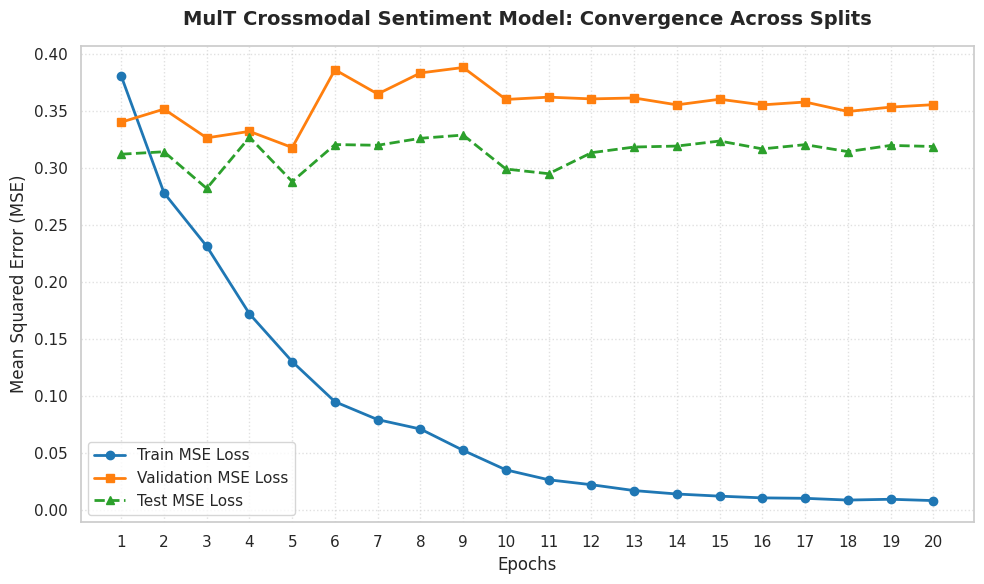

In [ ]:
# Step 6: Training, Validation, and Test Loop with Metric Tracking & Loss Plotting
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# 1. Setup Loss Function, Optimizer, and Scheduler
criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

epochs = 20
train_losses = []
valid_losses = []
test_losses = []

print("🚀 --- STARTING TRAINING LOOP WITH MULTI-SPLIT LOSS MONITORING ---")
print(f"{'Epoch':^7} | {'Train MSE':^12} | {'Valid MSE':^12} | {'Test MSE':^12} | {'Status'}")
print("-" * 60)

# 2. Epoch Training Loop
for epoch in range(1, epochs + 1):
    # --- TRAIN PHASE ---
    model.train()
    running_train_loss = 0.0
    for t_batch, a_batch, v_batch, labels in train_loader:
        t_batch = t_batch.to(device)
        a_batch = a_batch.to(device)
        v_batch = v_batch.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        preds = model(t_batch, a_batch, v_batch).squeeze()
        loss = criterion(preds, labels)
        loss.backward()

        # Gradient clipping to ensure optimization stability
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_train_loss += loss.item() * len(labels)

    epoch_train_loss = running_train_loss / len(train_dataset)
    train_losses.append(epoch_train_loss)

    # --- VALIDATION PHASE ---
    model.eval()
    running_valid_loss = 0.0
    with torch.no_grad():
        for t_batch, a_batch, v_batch, labels in valid_loader:
            t_batch = t_batch.to(device)
            a_batch = a_batch.to(device)
            v_batch = v_batch.to(device)
            labels = labels.to(device)

            preds = model(t_batch, a_batch, v_batch).squeeze()
            loss = criterion(preds, labels)
            running_valid_loss += loss.item() * len(labels)

    epoch_valid_loss = running_valid_loss / len(valid_dataset)
    valid_losses.append(epoch_valid_loss)

    # --- TEST MONITORING PHASE ---
    running_test_loss = 0.0
    with torch.no_grad():
        for t_batch, a_batch, v_batch, labels in test_loader:
            t_batch = t_batch.to(device)
            a_batch = a_batch.to(device)
            v_batch = v_batch.to(device)
            labels = labels.to(device)

            preds = model(t_batch, a_batch, v_batch).squeeze()
            loss = criterion(preds, labels)
            running_test_loss += loss.item() * len(labels)

    epoch_test_loss = running_test_loss / len(test_dataset)
    test_losses.append(epoch_test_loss)

    # Learning rate step based on validation loss
    scheduler.step(epoch_valid_loss)

    # Print explicit epoch status
    print(f"{epoch:^7d} | {epoch_train_loss:^12.4f} | {epoch_valid_loss:^12.4f} | {epoch_test_loss:^12.4f} | OK")

print("-" * 60)
print("✅ Training Complete!")

# 3. Plot Train, Validation, and Test Loss Curves
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), train_losses, label='Train MSE Loss', color='#1f77b4', linewidth=2, marker='o')
plt.plot(range(1, epochs + 1), valid_losses, label='Validation MSE Loss', color='#ff7f0e', linewidth=2, marker='s')
plt.plot(range(1, epochs + 1), test_losses, label='Test MSE Loss', color='#2ca02c', linewidth=2, marker='^', linestyle='--')

plt.title('MulT Crossmodal Sentiment Model: Convergence Across Splits', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Mean Squared Error (MSE)', fontsize=12)
plt.xticks(range(1, epochs + 1))
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
# Step 7: Comprehensive Evaluation (Accuracy, F1-Score, MAE, Pearson Correlation)
import torch
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, mean_absolute_error
from scipy.stats import pearsonr

# 1. Collect all predictions and ground truth labels from the Test set
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for t_batch, a_batch, v_batch, labels in test_loader:
        t_batch = t_batch.to(device)
        a_batch = a_batch.to(device)
        v_batch = v_batch.to(device)

        preds = model(t_batch, a_batch, v_batch).squeeze()

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# 2. Regression Metrics: MAE and Pearson Correlation (r)
mae = mean_absolute_error(all_labels, all_preds)
corr, _ = pearsonr(all_preds, all_labels)

# 3. Binary Classification Metrics (Non-negative vs Negative Sentiment)
binary_truth = all_labels >= 0
binary_preds = all_preds >= 0

acc_2 = accuracy_score(binary_truth, binary_preds)
f1_macro_2 = f1_score(binary_truth, binary_preds, average='macro')
f1_weighted_2 = f1_score(binary_truth, binary_preds, average='weighted')

# 4. Multiclass Metrics (7-Class Classification: -3, -2, -1, 0, 1, 2, 3)
multiclass_truth = np.clip(np.round(all_labels), -3, 3)
multiclass_preds = np.clip(np.round(all_preds), -3, 3)

acc_7 = accuracy_score(multiclass_truth, multiclass_preds)
f1_macro_7 = f1_score(multiclass_truth, multiclass_preds, average='macro')

# 5. Display Evaluation Summary Table
print("=" * 60)
print("📊 --- FINAL TEST EVALUATION METRICS ---")
print("=" * 60)
print(f"{'Metric':<30} | {'Value':<10}")
print("-" * 60)
print(f"{'Mean Absolute Error (MAE)':<30} | {mae:.4f}")
print(f"{'Pearson Correlation (r)':<30} | {corr:.4f}")
print(f"{'Binary Accuracy (Acc-2)':<30} | {acc_2 * 100:.2f}%")
print(f"{'Binary F1-Score (Macro)':<30} | {f1_macro_2:.4f}")
print(f"{'Binary F1-Score (Weighted)':<30} | {f1_weighted_2:.4f}")
print(f"{'7-Class Accuracy (Acc-7)':<30} | {acc_7 * 100:.2f}%")
print(f"{'7-Class F1-Score (Macro)':<30} | {f1_macro_7:.4f}")
print("=" * 60)

📊 --- FINAL TEST EVALUATION METRICS ---
Metric                         | Value     
------------------------------------------------------------
Mean Absolute Error (MAE)      | 0.4074
Pearson Correlation (r)        | 0.6313
Binary Accuracy (Acc-2)        | 71.99%
Binary F1-Score (Macro)        | 0.7094
Binary F1-Score (Weighted)     | 0.7141
7-Class Accuracy (Acc-7)       | 61.93%
7-Class F1-Score (Macro)       | 0.6192


In [ ]:
# Step 8: Qualitative Inference & Batch Inspection on Test Set
import pandas as pd
import numpy as np

# Set model to evaluation mode
model.eval()

# Retrieve a single batch of test samples
sample_t, sample_a, sample_v, sample_labels = next(iter(test_loader))

# Perform inference on the batch
with torch.no_grad():
    sample_t_dev = sample_t.to(device)
    sample_a_dev = sample_a.to(device)
    sample_v_dev = sample_v.to(device)

    preds = model(sample_t_dev, sample_a_dev, sample_v_dev).squeeze().cpu().numpy()

ground_truth = sample_labels.numpy()

# Helper function to categorize continuous sentiment scores into human-readable labels
def get_sentiment_label(score):
    if score >= 1.0:
        return "Strongly Positive"
    elif score > 0.1:
        return "Positive"
    elif score >= -0.1:
        return "Neutral"
    elif score > -1.0:
        return "Negative"
    else:
        return "Strongly Negative"

# Build an inspection DataFrame for the first 10 samples
num_inspect = 10
results_df = pd.DataFrame({
    'Sample Index': np.arange(1, num_inspect + 1),
    'Ground Truth': np.round(ground_truth[:num_inspect], 4),
    'Model Prediction': np.round(preds[:num_inspect], 4),
    'Absolute Error': np.round(np.abs(ground_truth[:num_inspect] - preds[:num_inspect]), 4),
    'True Sentiment': [get_sentiment_label(val) for val in ground_truth[:num_inspect]],
    'Predicted Sentiment': [get_sentiment_label(val) for val in preds[:num_inspect]]
})

print("=" * 100)
print("🔍 --- QUALITATIVE INFERENCE: SAMPLE TEST PREDICTIONS ---")
print("=" * 100)
print(results_df.to_string(index=False))
print("=" * 100)

# Batch summary statistics for the inspection subset
print(f"Batch Sample MAE: {np.mean(results_df['Absolute Error']):.4f}")
print(f"Polarity Match Rate: {(results_df['True Sentiment'] == results_df['Predicted Sentiment']).mean() * 100:.1f}%")

🔍 --- QUALITATIVE INFERENCE: SAMPLE TEST PREDICTIONS ---
 Sample Index  Ground Truth  Model Prediction  Absolute Error    True Sentiment Predicted Sentiment
            1          -1.0            0.0599          1.0599 Strongly Negative             Neutral
            2          -0.8           -0.8869          0.0869          Negative            Negative
            3           1.0            0.7056          0.2944 Strongly Positive            Positive
            4          -0.2            0.6245          0.8245          Negative            Positive
            5           0.8            0.6223          0.1777          Positive            Positive
            6           0.8            0.7738          0.0262          Positive            Positive
            7          -0.4           -0.4761          0.0761          Negative            Negative
            8           0.4            0.2637          0.1363          Positive            Positive
            9          -1.0           -1.09